# Deteksi Penyakit Daun Kentang

## Menggunakan Random Forest

Notebook ini merupakan model pembanding untuk klasifikasi tiga kondisi daun kentang:

1. Early Blight (Bercak Awal)
2. Late Blight (Bercak Akhir)
3. Healthy (Sehat)

Random Forest tidak menerima citra mentah secara langsung seperti CNN. Oleh karena itu, setiap gambar diubah menjadi vektor fitur menggunakan HOG, histogram warna RGB dan HSV, Local Binary Pattern, serta statistik warna. Vektor fitur tersebut kemudian digunakan untuk melatih Random Forest.

In [1]:
# CELL 1: Instalasi Library Tambahan
# scikit-image digunakan untuk ekstraksi fitur HOG dan Local Binary Pattern.
!pip -q install scikit-image joblib

In [2]:
# CELL 2: Import Library
import os
import random
import zipfile
import shutil
import json
import hashlib
import warnings
from collections import Counter, defaultdict

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display
from skimage.color import rgb2gray, rgb2hsv
from skimage.feature import hog, local_binary_pattern

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

# Seed dibuat tetap agar pembagian data dan pelatihan dapat direproduksi.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Konfigurasi tampilan grafik.
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 8)

print("Semua library berhasil diimport.")
print("Random Forest berjalan menggunakan CPU. GPU T4 tidak diperlukan.")

Semua library berhasil diimport.
Random Forest berjalan menggunakan CPU. GPU T4 tidak diperlukan.


---

## 1. Data Collection

Upload dataset dalam bentuk ZIP. Struktur folder yang diharapkan:

```text
PlantVillage/
|-- Potato___Early_blight/
|-- Potato___Late_blight/
`-- Potato___healthy/
```

In [3]:
# CELL 3: Upload Dataset
from google.colab import files

print("=" * 60)
print("UPLOAD DATASET")
print("=" * 60)
print("Upload file ZIP dataset daun kentang.")
print("Dataset referensi: https://www.kaggle.com/datasets/arajmishra/potato-dataset")

uploaded = files.upload()

# Seluruh file ZIP yang diunggah diekstrak ke direktori kerja Colab.
for filename in uploaded.keys():
    if not filename.lower().endswith(".zip"):
        print(f"{filename} dilewati karena bukan file ZIP.")
        continue

    print(f"Mengekstrak {filename}...")
    with zipfile.ZipFile(filename, "r") as zip_ref:
        zip_ref.extractall(".")

print("Proses upload dan ekstraksi selesai.")

UPLOAD DATASET
Upload file ZIP dataset daun kentang.
Dataset referensi: https://www.kaggle.com/datasets/arajmishra/potato-dataset


Saving archive (1).zip to archive (1).zip
Mengekstrak archive (1).zip...
Proses upload dan ekstraksi selesai.


In [4]:
# CELL 4: Setup dan Pemeriksaan Dataset
print("=" * 60)
print("SETUP DAN PEMERIKSAAN DATASET")
print("=" * 60)

CLASS_NAMES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

CLASS_LABELS = {
    "Potato___Early_blight": "Early Blight (Bercak Awal)",
    "Potato___Late_blight": "Late Blight (Bercak Akhir)",
    "Potato___healthy": "Healthy (Sehat)"
}

NUM_CLASSES = len(CLASS_NAMES)
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

# Cari folder sumber yang secara langsung memiliki ketiga folder kelas.
# Folder hasil split bernama dataset dilewati agar tidak dianggap sebagai sumber.
IMG_DIR = None
for root, dirs, _ in os.walk("."):
    normalized_root = os.path.normpath(root)
    root_parts = normalized_root.split(os.sep)

    if "dataset" in root_parts or "Model_RF" in root_parts:
        continue

    if all(class_name in dirs for class_name in CLASS_NAMES):
        IMG_DIR = root
        break

if IMG_DIR is None:
    raise FileNotFoundError(
        "Folder sumber tidak ditemukan. Pastikan ZIP berisi tiga folder kelas "
        "Potato___Early_blight, Potato___Late_blight, dan Potato___healthy."
    )

print(f"Folder dataset ditemukan: {IMG_DIR}")
print("\nDistribusi dataset sumber:")
print("-" * 50)

for class_name in CLASS_NAMES:
    class_dir = os.path.join(IMG_DIR, class_name)
    image_files = [
        filename for filename in os.listdir(class_dir)
        if filename.lower().endswith(IMAGE_EXTENSIONS)
    ]
    print(f"{CLASS_LABELS[class_name]:35s}: {len(image_files):5d} gambar")

SETUP DAN PEMERIKSAAN DATASET
Folder dataset ditemukan: ./PlantVillage

Distribusi dataset sumber:
--------------------------------------------------
Early Blight (Bercak Awal)         :  1000 gambar
Late Blight (Bercak Akhir)         :  1000 gambar
Healthy (Sehat)                    :   152 gambar


In [5]:
# CELL 5: Split Dataset
print("=" * 60)
print("SPLIT DATASET (TRAIN 70% | VALIDATION 10% | TEST 20%)")
print("=" * 60)

DEST_DIR = "dataset"

# Folder split lama dihapus agar tidak ada file tersisa ketika cell dijalankan ulang.
if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)

for split_name in ["train", "val", "test"]:
    for class_name in CLASS_NAMES:
        os.makedirs(
            os.path.join(DEST_DIR, split_name, class_name),
            exist_ok=True
        )

total_counts = {"train": 0, "val": 0, "test": 0}

for class_name in CLASS_NAMES:
    source_dir = os.path.join(IMG_DIR, class_name)
    image_files = sorted([
        filename for filename in os.listdir(source_dir)
        if filename.lower().endswith(IMAGE_EXTENSIONS)
    ])

    if not image_files:
        raise ValueError(f"Tidak ada gambar pada kelas {class_name}.")

    # Pembagian dilakukan per kelas agar proporsi kelas tetap terjaga.
    train_files, temporary_files = train_test_split(
        image_files,
        test_size=0.30,
        random_state=SEED
    )

    validation_files, test_files = train_test_split(
        temporary_files,
        test_size=2 / 3,
        random_state=SEED
    )

    split_files = {
        "train": train_files,
        "val": validation_files,
        "test": test_files
    }

    for split_name, filenames in split_files.items():
        for filename in filenames:
            shutil.copy2(
                os.path.join(source_dir, filename),
                os.path.join(DEST_DIR, split_name, class_name, filename)
            )
        total_counts[split_name] += len(filenames)

    print(
        f"{CLASS_LABELS[class_name]:30s}: "
        f"Train={len(train_files):4d}, "
        f"Val={len(validation_files):4d}, "
        f"Test={len(test_files):4d}"
    )

print("-" * 60)
print(
    f"{'TOTAL':30s}: "
    f"Train={total_counts['train']:4d}, "
    f"Val={total_counts['val']:4d}, "
    f"Test={total_counts['test']:4d}"
)

SPLIT DATASET (TRAIN 70% | VALIDATION 10% | TEST 20%)
Early Blight (Bercak Awal)    : Train= 700, Val= 100, Test= 200
Late Blight (Bercak Akhir)    : Train= 700, Val= 100, Test= 200
Healthy (Sehat)               : Train= 106, Val=  15, Test=  31
------------------------------------------------------------
TOTAL                         : Train=1506, Val= 215, Test= 431


---

## 2. Exploratory Data Analysis

EXPLORATORY DATA ANALYSIS


,Split,Kelas,Jumlah
0,train,Early Blight (Bercak Awal),700
1,train,Late Blight (Bercak Akhir),700
2,train,Healthy (Sehat),106
3,val,Early Blight (Bercak Awal),100
4,val,Late Blight (Bercak Akhir),100
5,val,Healthy (Sehat),15
6,test,Early Blight (Bercak Awal),200
7,test,Late Blight (Bercak Akhir),200
8,test,Healthy (Sehat),31


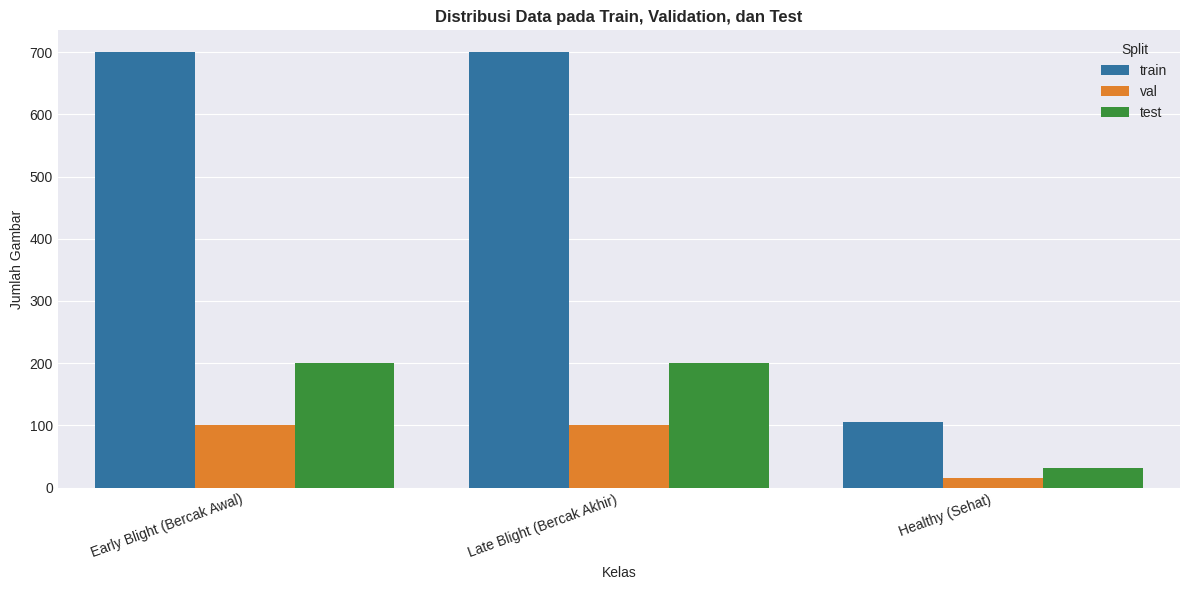

In [6]:
# CELL 6: Distribusi Kelas
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

distribution_records = []

for split_name in ["train", "val", "test"]:
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(DEST_DIR, split_name, class_name)
        count = len([
            filename for filename in os.listdir(class_dir)
            if filename.lower().endswith(IMAGE_EXTENSIONS)
        ])

        distribution_records.append({
            "Split": split_name,
            "Kelas": CLASS_LABELS[class_name],
            "Jumlah": count
        })

distribution_df = pd.DataFrame(distribution_records)
display(distribution_df)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=distribution_df,
    x="Kelas",
    y="Jumlah",
    hue="Split",
    ax=ax
)
ax.set_title("Distribusi Data pada Train, Validation, dan Test", fontweight="bold")
ax.set_xlabel("Kelas")
ax.set_ylabel("Jumlah Gambar")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

SAMPEL GAMBAR PER KELAS


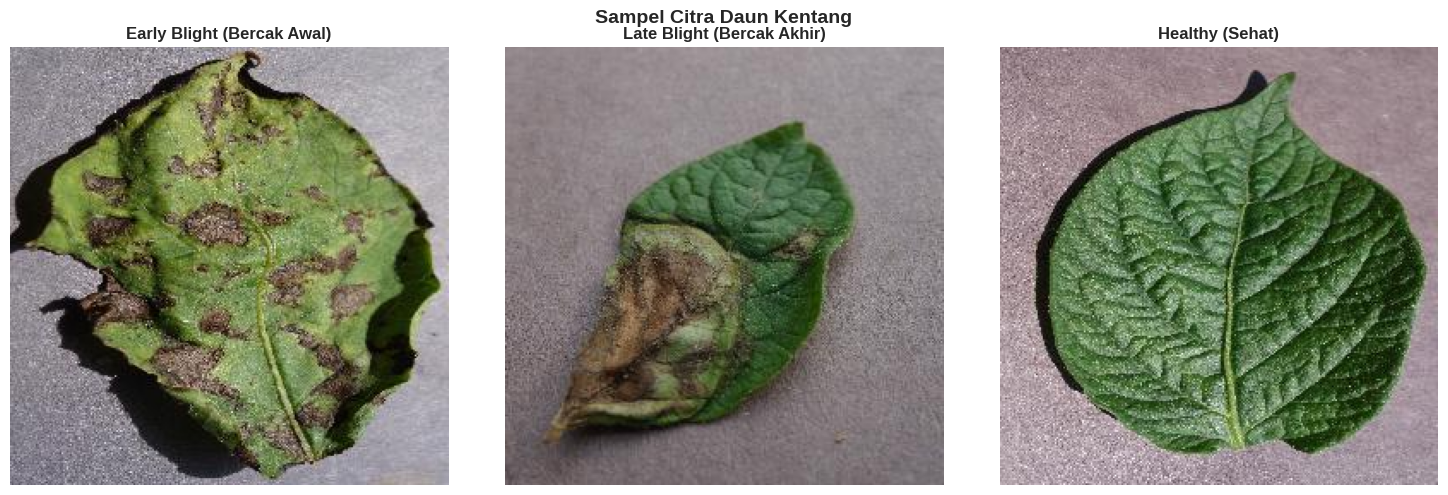

In [7]:
# CELL 7: Sampel Gambar per Kelas
print("=" * 60)
print("SAMPEL GAMBAR PER KELAS")
print("=" * 60)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(15, 5))

for class_index, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DEST_DIR, "train", class_name)
    image_files = sorted([
        filename for filename in os.listdir(class_dir)
        if filename.lower().endswith(IMAGE_EXTENSIONS)
    ])

    sample_path = os.path.join(class_dir, image_files[0])
    sample_image = Image.open(sample_path).convert("RGB")

    axes[class_index].imshow(sample_image)
    axes[class_index].set_title(CLASS_LABELS[class_name], fontweight="bold")
    axes[class_index].axis("off")

plt.suptitle("Sampel Citra Daun Kentang", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
# CELL 8: Pemeriksaan Ukuran Citra, File Rusak, dan Duplikasi
print("=" * 60)
print("PEMERIKSAAN KUALITAS DATA")
print("=" * 60)

image_sizes = []
corrupt_files = []
hash_groups = defaultdict(list)

for split_name in ["train", "val", "test"]:
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(DEST_DIR, split_name, class_name)

        for filename in os.listdir(class_dir):
            if not filename.lower().endswith(IMAGE_EXTENSIONS):
                continue

            file_path = os.path.join(class_dir, filename)

            try:
                with Image.open(file_path) as image:
                    image_sizes.append(image.size)
                    image.verify()

                # Hash digunakan untuk mencari file yang identik.
                with open(file_path, "rb") as file_obj:
                    file_hash = hashlib.sha256(file_obj.read()).hexdigest()

                hash_groups[file_hash].append({
                    "split": split_name,
                    "class_name": class_name,
                    "filename": filename
                })
            except Exception as error:
                corrupt_files.append((file_path, str(error)))

size_counter = Counter(image_sizes)
duplicate_groups = [
    records for records in hash_groups.values()
    if len(records) > 1
]
cross_split_duplicates = [
    records for records in duplicate_groups
    if len({record["split"] for record in records}) > 1
]

print(f"Total gambar diperiksa: {len(image_sizes)}")
print(f"File rusak: {len(corrupt_files)}")
print(f"Kelompok duplikat identik: {len(duplicate_groups)}")
print(f"Duplikat lintas split: {len(cross_split_duplicates)}")

if image_sizes:
    widths = [size[0] for size in image_sizes]
    heights = [size[1] for size in image_sizes]

    print(f"Ukuran minimum: {min(widths)} x {min(heights)} piksel")
    print(f"Ukuran maksimum: {max(widths)} x {max(heights)} piksel")
    print(f"Ukuran paling umum: {size_counter.most_common(1)[0][0]}")

if cross_split_duplicates:
    print("\nPeringatan: ditemukan gambar identik pada split yang berbeda.")
    for group_number, records in enumerate(cross_split_duplicates[:5], start=1):
        locations = [
            f"{record['split']}/{record['class_name']}/{record['filename']}"
            for record in records
        ]
        print(f"Grup {group_number}: {' | '.join(locations)}")
else:
    print("Tidak ditemukan gambar identik yang melintasi train, validation, dan test.")

PEMERIKSAAN KUALITAS DATA
Total gambar diperiksa: 2152
File rusak: 0
Kelompok duplikat identik: 0
Duplikat lintas split: 0
Ukuran minimum: 256 x 256 piksel
Ukuran maksimum: 256 x 256 piksel
Ukuran paling umum: (256, 256)
Tidak ditemukan gambar identik yang melintasi train, validation, dan test.


---

## 3. Data Processing

Setiap gambar diubah ke ukuran `128 x 128` piksel dan dikonversi ke RGB. Random Forest menggunakan vektor fitur numerik, sehingga citra tidak diberikan secara langsung ke model.

Augmentasi tidak diterapkan pada notebook Random Forest ini. Ketidakseimbangan kelas ditangani menggunakan `class_weight="balanced_subsample"`.

In [9]:
# CELL 9: Konfigurasi Preprocessing dan Feature Engineering
print("=" * 60)
print("KONFIGURASI PREPROCESSING")
print("=" * 60)

IMG_SIZE = 128

# Parameter HOG.
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

# Parameter histogram warna.
COLOR_HIST_BINS = 32

# Parameter Local Binary Pattern.
LBP_POINTS = 24
LBP_RADIUS = 3
LBP_BINS = LBP_POINTS + 2

print(f"Ukuran gambar: {IMG_SIZE} x {IMG_SIZE}")
print(f"HOG orientations: {HOG_ORIENTATIONS}")
print(f"Histogram warna per kanal: {COLOR_HIST_BINS} bin")
print(f"LBP points: {LBP_POINTS}")

KONFIGURASI PREPROCESSING
Ukuran gambar: 128 x 128
HOG orientations: 9
Histogram warna per kanal: 32 bin
LBP points: 24


---

## 4. Feature Engineering

Fitur yang digunakan:

- **HOG** untuk menangkap bentuk, tepi, dan tekstur bercak.
- **Histogram RGB** untuk menangkap distribusi warna merah, hijau, dan biru.
- **Histogram HSV** untuk menangkap hue, saturation, dan brightness.
- **Local Binary Pattern** untuk menangkap tekstur lokal permukaan daun.
- **Statistik warna** berupa nilai rata-rata dan standar deviasi setiap kanal.

In [10]:
# CELL 10: Fungsi Ekstraksi Fitur
def normalize_histogram(histogram):
    # Histogram dinormalisasi agar tidak bergantung pada jumlah piksel.
    histogram = histogram.astype(np.float32)
    histogram_sum = histogram.sum()

    if histogram_sum > 0:
        histogram = histogram / histogram_sum

    return histogram


def extract_image_features(image_path, image_size=IMG_SIZE):
    # Baca gambar, ubah ke RGB, lalu samakan ukuran input.
    with Image.open(image_path) as image:
        image = image.convert("RGB")
        image = image.resize((image_size, image_size))
        rgb_image = np.asarray(image, dtype=np.float32) / 255.0

    gray_image = rgb2gray(rgb_image)
    hsv_image = rgb2hsv(rgb_image)

    # HOG menangkap pola gradien, bentuk, dan tepi pada citra.
    hog_features = hog(
        gray_image,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        feature_vector=True
    ).astype(np.float32)

    # Histogram RGB dan HSV menangkap distribusi warna daun.
    rgb_histograms = []
    hsv_histograms = []

    for channel_index in range(3):
        rgb_hist, _ = np.histogram(
            rgb_image[:, :, channel_index],
            bins=COLOR_HIST_BINS,
            range=(0.0, 1.0)
        )
        hsv_hist, _ = np.histogram(
            hsv_image[:, :, channel_index],
            bins=COLOR_HIST_BINS,
            range=(0.0, 1.0)
        )

        rgb_histograms.append(normalize_histogram(rgb_hist))
        hsv_histograms.append(normalize_histogram(hsv_hist))

    rgb_hist_features = np.concatenate(rgb_histograms)
    hsv_hist_features = np.concatenate(hsv_histograms)

    # LBP digunakan untuk merepresentasikan tekstur lokal daun.
    gray_uint8 = np.clip(gray_image * 255, 0, 255).astype(np.uint8)
    lbp_image = local_binary_pattern(
        gray_uint8,
        P=LBP_POINTS,
        R=LBP_RADIUS,
        method="uniform"
    )
    lbp_hist, _ = np.histogram(
        lbp_image.ravel(),
        bins=np.arange(0, LBP_BINS + 1),
        range=(0, LBP_BINS)
    )
    lbp_features = normalize_histogram(lbp_hist)

    # Statistik sederhana membantu menangkap karakter warna secara global.
    rgb_means = rgb_image.mean(axis=(0, 1))
    rgb_stds = rgb_image.std(axis=(0, 1))
    hsv_means = hsv_image.mean(axis=(0, 1))
    hsv_stds = hsv_image.std(axis=(0, 1))

    statistics_features = np.concatenate([
        rgb_means,
        rgb_stds,
        hsv_means,
        hsv_stds
    ]).astype(np.float32)

    return np.concatenate([
        hog_features,
        rgb_hist_features,
        hsv_hist_features,
        lbp_features,
        statistics_features
    ]).astype(np.float32)


# Uji fungsi pada satu gambar untuk memastikan dimensi fitur konsisten.
sample_class_dir = os.path.join(DEST_DIR, "train", CLASS_NAMES[0])
sample_filename = sorted(os.listdir(sample_class_dir))[0]
sample_path = os.path.join(sample_class_dir, sample_filename)

sample_features = extract_image_features(sample_path)
FEATURE_DIMENSION = len(sample_features)

print(f"Jumlah fitur per gambar: {FEATURE_DIMENSION}")
print("Fungsi ekstraksi fitur berhasil diuji.")

Jumlah fitur per gambar: 1994
Fungsi ekstraksi fitur berhasil diuji.


In [11]:
# CELL 11: Ekstraksi Fitur Seluruh Dataset
def collect_split_data(split_name):
    feature_rows = []
    labels = []
    file_paths = []

    for class_index, class_name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(DEST_DIR, split_name, class_name)
        image_files = sorted([
            filename for filename in os.listdir(class_dir)
            if filename.lower().endswith(IMAGE_EXTENSIONS)
        ])

        for filename in tqdm(
            image_files,
            desc=f"Ekstraksi {split_name} - {class_name}",
            leave=False
        ):
            file_path = os.path.join(class_dir, filename)

            try:
                features = extract_image_features(file_path)
                feature_rows.append(features)
                labels.append(class_index)
                file_paths.append(file_path)
            except Exception as error:
                print(f"File dilewati: {file_path} | {error}")

    if not feature_rows:
        raise ValueError(f"Tidak ada fitur yang berhasil diekstrak dari split {split_name}.")

    return (
        np.vstack(feature_rows).astype(np.float32),
        np.asarray(labels, dtype=np.int64),
        np.asarray(file_paths)
    )


print("=" * 60)
print("EKSTRAKSI FITUR DATASET")
print("=" * 60)

X_train, y_train, train_paths = collect_split_data("train")
X_val, y_val, val_paths = collect_split_data("val")
X_test, y_test, test_paths = collect_split_data("test")

print("\nBentuk data:")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")

# Simpan fitur agar cell training dapat dijalankan ulang tanpa ekstraksi ulang.
np.savez_compressed(
    "potato_rf_features.npz",
    X_train=X_train,
    y_train=y_train,
    train_paths=train_paths,
    X_val=X_val,
    y_val=y_val,
    val_paths=val_paths,
    X_test=X_test,
    y_test=y_test,
    test_paths=test_paths
)

print("Cache fitur tersimpan: potato_rf_features.npz")

EKSTRAKSI FITUR DATASET


Ekstraksi train - Potato___Early_blight:   0%|          | 0/700 [00:00<?, ?it/s]

Ekstraksi train - Potato___Late_blight:   0%|          | 0/700 [00:00<?, ?it/s]

Ekstraksi train - Potato___healthy:   0%|          | 0/106 [00:00<?, ?it/s]

Ekstraksi val - Potato___Early_blight:   0%|          | 0/100 [00:00<?, ?it/s]

...

Ekstraksi val - Potato___healthy:   0%|          | 0/15 [00:00<?, ?it/s]

Ekstraksi test - Potato___Early_blight:   0%|          | 0/200 [00:00<?, ?it/s]

Ekstraksi test - Potato___Late_blight:   0%|          | 0/200 [00:00<?, ?it/s]

Ekstraksi test - Potato___healthy:   0%|          | 0/31 [00:00<?, ?it/s]


Bentuk data:
X_train: (1506, 1994) | y_train: (1506,)
X_val:   (215, 1994) | y_val:   (215,)
X_test:  (431, 1994) | y_test:  (431,)
Cache fitur tersimpan: potato_rf_features.npz


---

## 5. Modelling Random Forest

In [12]:
# CELL 12: Membangun dan Melatih Random Forest
print("=" * 60)
print("PELATIHAN RANDOM FOREST")
print("=" * 60)

# balanced_subsample menghitung bobot kelas pada setiap bootstrap sample.
# Pembatasan max_depth digunakan untuk membantu mengurangi overfitting.
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)

print("\nPelatihan selesai.")
print(f"Jumlah pohon: {rf_model.n_estimators}")
print(f"Jumlah fitur: {rf_model.n_features_in_}")
print(f"OOB Score: {rf_model.oob_score_:.4f}")

PELATIHAN RANDOM FOREST


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:   13.6s finished



Pelatihan selesai.
Jumlah pohon: 400
Jumlah fitur: 1994
OOB Score: 0.9582


In [13]:
# CELL 13: Evaluasi Train dan Validation
print("=" * 60)
print("EVALUASI TRAIN DAN VALIDATION")
print("=" * 60)

train_predictions = rf_model.predict(X_train)
validation_predictions = rf_model.predict(X_val)

train_accuracy = accuracy_score(y_train, train_predictions)
validation_accuracy = accuracy_score(y_val, validation_predictions)

train_macro_f1 = f1_score(
    y_train,
    train_predictions,
    average="macro",
    zero_division=0
)
validation_macro_f1 = f1_score(
    y_val,
    validation_predictions,
    average="macro",
    zero_division=0
)

accuracy_gap = train_accuracy - validation_accuracy
f1_gap = train_macro_f1 - validation_macro_f1

print(f"Training Accuracy:   {train_accuracy:.4f} ({train_accuracy * 100:.2f}%)")
print(f"Validation Accuracy: {validation_accuracy:.4f} ({validation_accuracy * 100:.2f}%)")
print(f"Accuracy Gap:        {accuracy_gap:.4f}")
print(f"Training Macro F1:   {train_macro_f1:.4f}")
print(f"Validation Macro F1: {validation_macro_f1:.4f}")
print(f"Macro F1 Gap:        {f1_gap:.4f}")
print(f"OOB Score:           {rf_model.oob_score_:.4f}")

print("\nInterpretasi awal:")
if train_accuracy < 0.70 and validation_accuracy < 0.70:
    print("Terdapat indikasi underfitting karena performa train dan validation masih rendah.")
elif accuracy_gap > 0.10 or f1_gap > 0.10:
    print("Terdapat indikasi overfitting yang kuat karena gap train dan validation lebih dari 10%.")
elif accuracy_gap > 0.05 or f1_gap > 0.05:
    print("Terdapat indikasi overfitting ringan karena gap train dan validation lebih dari 5%.")
else:
    print("Tidak terdapat indikasi overfitting atau underfitting yang signifikan.")

EVALUASI TRAIN DAN VALIDATION


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 400 out of 400 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s


Training Accuracy:   1.0000 (100.00%)
Validation Accuracy: 0.9581 (95.81%)
Accuracy Gap:        0.0419
Training Macro F1:   1.0000
Validation Macro F1: 0.9122
Macro F1 Gap:        0.0878
OOB Score:           0.9582

Interpretasi awal:
Terdapat indikasi overfitting ringan karena gap train dan validation lebih dari 5%.


[Parallel(n_jobs=2)]: Done 400 out of 400 | elapsed:    0.1s finished


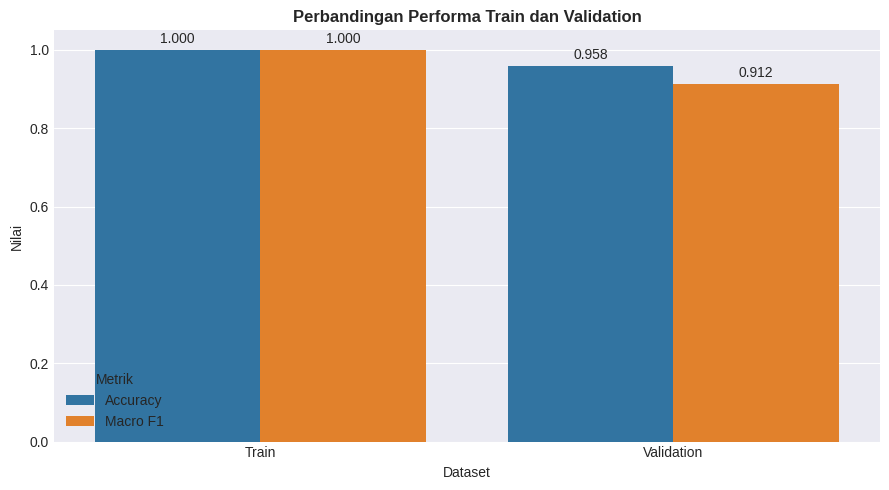

In [14]:
# CELL 14: Grafik Perbandingan Train dan Validation
metric_plot_df = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "Accuracy": [train_accuracy, validation_accuracy],
    "Macro F1": [train_macro_f1, validation_macro_f1]
})

metric_plot_long = metric_plot_df.melt(
    id_vars="Dataset",
    var_name="Metrik",
    value_name="Nilai"
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=metric_plot_long,
    x="Dataset",
    y="Nilai",
    hue="Metrik",
    ax=ax
)
ax.set_title("Perbandingan Performa Train dan Validation", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Nilai")
ax.set_xlabel("Dataset")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

ANALISIS FEATURE IMPORTANCE


,Kelompok Fitur,Importance
2,HSV Histogram,0.336725
1,RGB Histogram,0.274057
0,HOG,0.175502
3,LBP,0.161868
4,Color Statistics,0.051848


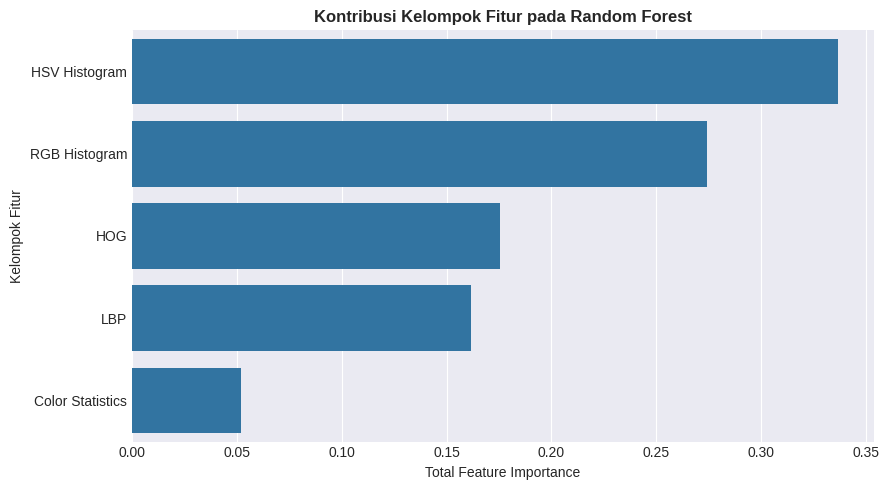

In [15]:
# CELL 15: Analisis Kelompok Feature Importance
print("=" * 60)
print("ANALISIS FEATURE IMPORTANCE")
print("=" * 60)

# Dimensi setiap kelompok fitur dihitung sesuai urutan pada fungsi ekstraksi.
hog_dimension = len(hog(
    np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32),
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    block_norm="L2-Hys",
    feature_vector=True
))
rgb_hist_dimension = COLOR_HIST_BINS * 3
hsv_hist_dimension = COLOR_HIST_BINS * 3
lbp_dimension = LBP_BINS
statistics_dimension = 12

feature_group_dimensions = {
    "HOG": hog_dimension,
    "RGB Histogram": rgb_hist_dimension,
    "HSV Histogram": hsv_hist_dimension,
    "LBP": lbp_dimension,
    "Color Statistics": statistics_dimension
}

importance_values = rf_model.feature_importances_
group_importance = {}
start_index = 0

for group_name, group_dimension in feature_group_dimensions.items():
    end_index = start_index + group_dimension
    group_importance[group_name] = float(
        importance_values[start_index:end_index].sum()
    )
    start_index = end_index

importance_df = pd.DataFrame({
    "Kelompok Fitur": list(group_importance.keys()),
    "Importance": list(group_importance.values())
}).sort_values("Importance", ascending=False)

display(importance_df)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Kelompok Fitur",
    ax=ax
)
ax.set_title("Kontribusi Kelompok Fitur pada Random Forest", fontweight="bold")
ax.set_xlabel("Total Feature Importance")
ax.set_ylabel("Kelompok Fitur")
plt.tight_layout()
plt.show()

---

## 6. Evaluation

MODEL EVALUATION


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 400 out of 400 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 400 out of 400 | elapsed:    0.1s finished



Hasil Evaluasi Model:
---------------------------------------------
Accuracy:           0.9559 (95.59%)
Weighted Precision: 0.9575
Weighted Recall:    0.9559
Weighted F1-Score:  0.9553
Macro Precision:    0.9695
Macro Recall:       0.9047
Macro F1-Score:     0.9321

Classification Report:
------------------------------------------------------------
                            precision    recall  f1-score   support

Early Blight (Bercak Awal)       0.98      0.96      0.97       200
Late Blight (Bercak Akhir)       0.93      0.98      0.95       200
           Healthy (Sehat)       1.00      0.77      0.87        31

                  accuracy                           0.96       431
                 macro avg       0.97      0.90      0.93       431
              weighted avg       0.96      0.96      0.96       431



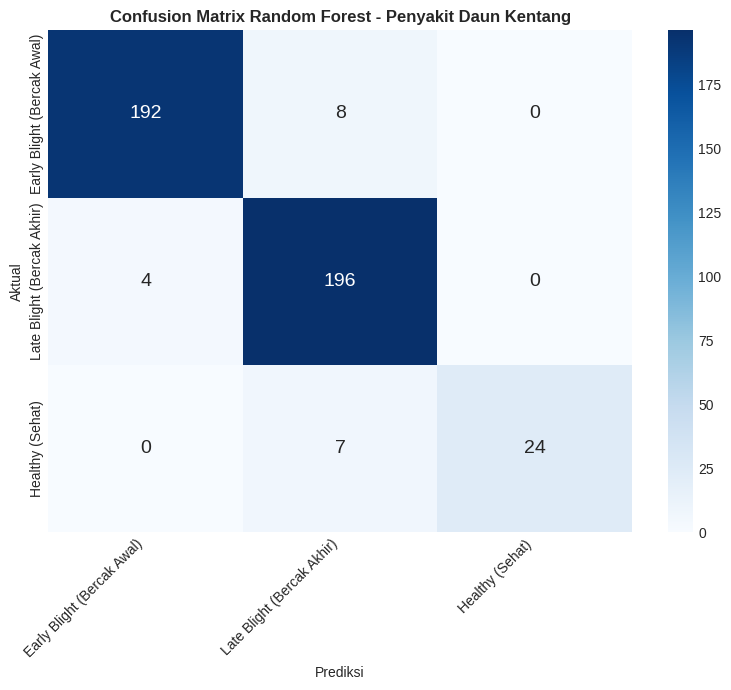

In [16]:
# CELL 16: Evaluasi pada Test Set
print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

test_predictions = rf_model.predict(X_test)
test_probabilities = rf_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, test_predictions)
weighted_precision = precision_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0
)
weighted_recall = recall_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0
)
weighted_f1 = f1_score(
    y_test,
    test_predictions,
    average="weighted",
    zero_division=0
)
macro_precision = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)
macro_recall = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)
macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

print("\nHasil Evaluasi Model:")
print("-" * 45)
print(f"Accuracy:           {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall:    {weighted_recall:.4f}")
print(f"Weighted F1-Score:  {weighted_f1:.4f}")
print(f"Macro Precision:    {macro_precision:.4f}")
print(f"Macro Recall:       {macro_recall:.4f}")
print(f"Macro F1-Score:     {macro_f1:.4f}")

class_names_display = [
    CLASS_LABELS[class_name]
    for class_name in CLASS_NAMES
]

print("\nClassification Report:")
print("-" * 60)
print(classification_report(
    y_test,
    test_predictions,
    target_names=class_names_display,
    zero_division=0
))

confusion_matrix_values = confusion_matrix(
    y_test,
    test_predictions
)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    confusion_matrix_values,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_display,
    yticklabels=class_names_display,
    annot_kws={"size": 14},
    ax=ax
)
ax.set_title(
    "Confusion Matrix Random Forest - Penyakit Daun Kentang",
    fontweight="bold"
)
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

RINGKASAN GENERALISASI MODEL


,Dataset,Accuracy
0,Train,1.000000
1,Validation,0.958140
2,Test,0.955916
3,OOB,0.958167


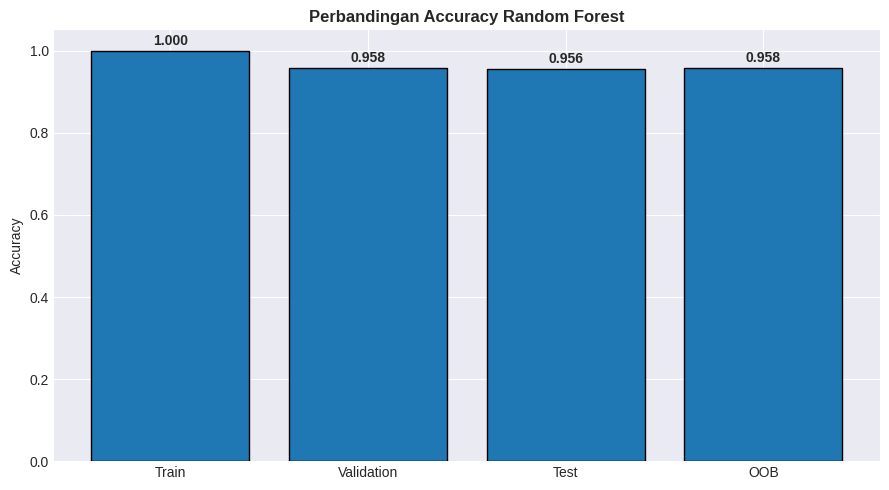

Gap generalisasi terbesar: 0.0441
Kesimpulan: terdapat indikasi overfitting ringan berdasarkan gap Macro F1 sebesar 8,78%.


In [17]:
# CELL 17: Ringkasan Overfitting dan Underfitting
print("=" * 60)
print("RINGKASAN GENERALISASI MODEL")
print("=" * 60)

generalization_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test", "OOB"],
    "Accuracy": [
        train_accuracy,
        validation_accuracy,
        accuracy,
        rf_model.oob_score_
    ]
})

display(generalization_df)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    generalization_df["Dataset"],
    generalization_df["Accuracy"],
    edgecolor="black"
)
ax.set_title("Perbandingan Accuracy Random Forest", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)

for bar, value in zip(bars, generalization_df["Accuracy"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

largest_generalization_gap = train_accuracy - min(
    validation_accuracy,
    accuracy,
    rf_model.oob_score_
)

print(f"Gap generalisasi terbesar: {largest_generalization_gap:.4f}")

generalization_indicator = max(largest_generalization_gap, f1_gap)

if train_accuracy < 0.70 and accuracy < 0.70:
    print("Kesimpulan: model mengalami indikasi underfitting.")
elif generalization_indicator > 0.10:
    print("Kesimpulan: model mengalami indikasi overfitting yang kuat.")
elif generalization_indicator > 0.05:
    print("Kesimpulan: model mengalami indikasi overfitting ringan.")
else:
    print("Kesimpulan: tidak terdapat overfitting atau underfitting yang signifikan.")

In [18]:
# CELL 18: Sampel Prediksi Test
print("=" * 60)
print("SAMPEL PREDIKSI TEST")
print("=" * 60)

rng = np.random.default_rng(SEED)
selected_indices = []

# Ambil minimal satu sampel dari setiap kelas.
for class_index in range(NUM_CLASSES):
    class_indices = np.where(y_test == class_index)[0]
    if len(class_indices) > 0:
        selected_indices.append(int(rng.choice(class_indices)))

remaining_count = min(8, len(y_test)) - len(selected_indices)
remaining_pool = np.setdiff1d(
    np.arange(len(y_test)),
    np.asarray(selected_indices, dtype=int)
)

if remaining_count > 0:
    selected_indices.extend(
        rng.choice(
            remaining_pool,
            size=remaining_count,
            replace=False
        ).tolist()
    )

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for plot_index, sample_index in enumerate(selected_indices):
    image_path = test_paths[sample_index]
    actual_index = int(y_test[sample_index])
    predicted_index = int(test_predictions[sample_index])
    confidence = float(test_probabilities[sample_index][predicted_index])

    display_image = Image.open(image_path).convert("RGB")

    axes[plot_index].imshow(display_image)
    title_color = "green" if actual_index == predicted_index else "red"
    axes[plot_index].set_title(
        f"Aktual: {CLASS_LABELS[CLASS_NAMES[actual_index]]}\n"
        f"Prediksi: {CLASS_LABELS[CLASS_NAMES[predicted_index]]}\n"
        f"Confidence: {confidence * 100:.1f}%",
        color=title_color,
        fontsize=9,
        fontweight="bold"
    )
    axes[plot_index].axis("off")

for plot_index in range(len(selected_indices), len(axes)):
    axes[plot_index].axis("off")

plt.suptitle("Prediksi Random Forest pada Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

---

## 7. Perbandingan dengan Model CNN

Nilai CNN di bawah berasal dari hasil evaluasi notebook CNN sebelumnya. Ubah nilainya apabila model CNN dilatih ulang dan menghasilkan metrik yang berbeda.

### Catatan Validitas Perbandingan

Hasil CNN dan Random Forest berasal dari pembagian data yang hampir sama, tetapi
terdapat perbedaan pembulatan pada data test:

- CNN: 433 data test, terdiri atas 201 Early Blight, 201 Late Blight, dan 31 Healthy.
- Random Forest: 431 data test, terdiri atas 200 Early Blight, 200 Late Blight, dan 31 Healthy.

Perbandingan metrik tetap berguna sebagai gambaran performa, tetapi eksperimen
yang sepenuhnya identik sebaiknya memakai daftar file split yang sama.

,Model,Accuracy,Weighted F1,Macro F1
0,CNN MobileNetV2,0.988500,0.988500,0.991700
1,Random Forest,0.955916,0.955332,0.932065


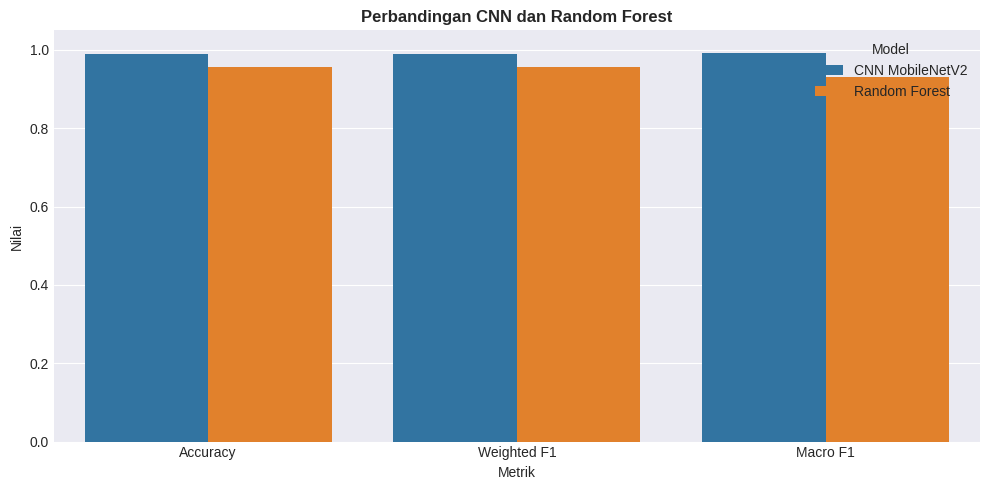

Model dengan accuracy tertinggi: CNN MobileNetV2


In [19]:
# CELL 19: Perbandingan Random Forest dan CNN
CNN_RESULTS = {
    "Model": "CNN MobileNetV2",
    "Accuracy": 0.9885,
    "Weighted F1": 0.9885,
    "Macro F1": 0.9917
}

RF_RESULTS = {
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "Weighted F1": weighted_f1,
    "Macro F1": macro_f1
}

comparison_df = pd.DataFrame([CNN_RESULTS, RF_RESULTS])
display(comparison_df)

comparison_long = comparison_df.melt(
    id_vars="Model",
    var_name="Metrik",
    value_name="Nilai"
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=comparison_long,
    x="Metrik",
    y="Nilai",
    hue="Model",
    ax=ax
)
ax.set_title("Perbandingan CNN dan Random Forest", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Nilai")
ax.set_xlabel("Metrik")
plt.tight_layout()
plt.show()

best_model_name = comparison_df.loc[
    comparison_df["Accuracy"].idxmax(),
    "Model"
]
print(f"Model dengan accuracy tertinggi: {best_model_name}")

---

## 8. Simpan Model

In [20]:
# CELL 20: Export Model Random Forest
print("=" * 60)
print("SIMPAN MODEL")
print("=" * 60)

MODEL_DIR = "Model_RF"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(
    MODEL_DIR,
    "potato_random_forest.joblib"
)

# Joblib sesuai untuk menyimpan model scikit-learn.
joblib.dump(rf_model, model_path, compress=3)

config = {
    "model_type": "RandomForestClassifier",
    "classes": CLASS_NAMES,
    "class_labels": CLASS_LABELS,
    "num_classes": NUM_CLASSES,
    "image_size": IMG_SIZE,
    "feature_dimension": FEATURE_DIMENSION,
    "feature_parameters": {
        "hog_orientations": HOG_ORIENTATIONS,
        "hog_pixels_per_cell": list(HOG_PIXELS_PER_CELL),
        "hog_cells_per_block": list(HOG_CELLS_PER_BLOCK),
        "color_hist_bins": COLOR_HIST_BINS,
        "lbp_points": LBP_POINTS,
        "lbp_radius": LBP_RADIUS
    },
    "test_accuracy": round(float(accuracy), 6),
    "weighted_f1": round(float(weighted_f1), 6),
    "macro_f1": round(float(macro_f1), 6)
}

config_path = os.path.join(
    MODEL_DIR,
    "random_forest_config.json"
)

with open(config_path, "w", encoding="utf-8") as file_obj:
    json.dump(config, file_obj, indent=2)

model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

print(f"Model tersimpan: {model_path}")
print(f"Konfigurasi tersimpan: {config_path}")
print(f"Ukuran model: {model_size_mb:.2f} MB")

print("\nIsi folder Model_RF:")
for filename in sorted(os.listdir(MODEL_DIR)):
    file_path = os.path.join(MODEL_DIR, filename)
    file_size_kb = os.path.getsize(file_path) / 1024
    print(f"{filename:35s} {file_size_kb:10.2f} KB")

SIMPAN MODEL
Model tersimpan: Model_RF/potato_random_forest.joblib
Konfigurasi tersimpan: Model_RF/random_forest_config.json
Ukuran model: 1.61 MB

Isi folder Model_RF:
potato_random_forest.joblib            1645.46 KB
random_forest_config.json                 0.70 KB


In [ ]:
# CELL 21: Download Model
from google.colab import files

print("Download model Random Forest.")
files.download("Model_RF/potato_random_forest.joblib")
files.download("Model_RF/random_forest_config.json")

---

## 9. Uji Coba Inference

In [ ]:
# CELL 22: Load Model dan Konfigurasi
print("=" * 60)
print("LOAD MODEL RANDOM FOREST")
print("=" * 60)

loaded_rf_model = joblib.load(
    "Model_RF/potato_random_forest.joblib"
)

with open(
    "Model_RF/random_forest_config.json",
    "r",
    encoding="utf-8"
) as file_obj:
    loaded_config = json.load(file_obj)

print("Model berhasil dimuat.")
print(f"Model: {loaded_config['model_type']}")
print(f"Jumlah kelas: {loaded_config['num_classes']}")
print(f"Test accuracy: {loaded_config['test_accuracy'] * 100:.2f}%")

In [ ]:
# CELL 23: Fungsi Prediksi
def predict_potato_disease_rf(
    image_path,
    model=loaded_rf_model,
    config=loaded_config
):
    # Ekstraksi fitur inference harus sama dengan tahap training.
    features = extract_image_features(
        image_path,
        image_size=int(config["image_size"])
    ).reshape(1, -1)

    predicted_index = int(model.predict(features)[0])
    probabilities = model.predict_proba(features)[0]
    confidence = float(probabilities[predicted_index])

    predicted_class = config["classes"][predicted_index]
    predicted_label = config["class_labels"][predicted_class]

    probability_per_class = {}
    for class_index, class_name in enumerate(config["classes"]):
        class_label = config["class_labels"][class_name]
        probability_per_class[class_label] = float(
            probabilities[class_index]
        )

    return {
        "disease": predicted_label,
        "disease_key": predicted_class,
        "confidence": confidence,
        "confidence_pct": f"{confidence * 100:.2f}%",
        "probabilities": probability_per_class
    }


print("Fungsi prediksi Random Forest siap digunakan.")

In [ ]:
# CELL 24: Upload Gambar dan Prediksi
from google.colab import files
from IPython.display import display

print("=" * 60)
print("UPLOAD GAMBAR UNTUK PREDIKSI")
print("=" * 60)

uploaded_images = files.upload()

for filename in uploaded_images.keys():
    if not filename.lower().endswith(IMAGE_EXTENSIONS):
        print(f"{filename} dilewati karena bukan file gambar yang didukung.")
        continue

    display_image = Image.open(filename).convert("RGB")
    display(display_image.resize((250, 250)))

    result = predict_potato_disease_rf(filename)

    print("\nHASIL PREDIKSI")
    print("-" * 50)
    print(f"Kelas: {result['disease']}")
    print(f"Confidence: {result['confidence_pct']}")

    print("\nProbabilitas per kelas:")
    for label, probability in result["probabilities"].items():
        bar = "#" * int(probability * 40)
        print(f"{label:35s}: {probability * 100:6.2f}% {bar}")

---

## Kesimpulan

Notebook ini menggunakan Random Forest sebagai model pembanding terhadap CNN MobileNetV2.

Tahapan yang dilakukan:

- pengumpulan dan pemeriksaan dataset;
- pembagian train, validation, dan test sebesar 70:10:20;
- exploratory data analysis;
- pemeriksaan file rusak dan duplikasi;
- preprocessing citra;
- feature engineering menggunakan HOG, RGB, HSV, LBP, dan statistik warna;
- pelatihan Random Forest;
- analisis train, validation, test, dan OOB score;
- evaluasi menggunakan accuracy, precision, recall, F1-score, classification report, dan confusion matrix;
- perbandingan dengan hasil CNN;
- export model ke format `.joblib`;
- pengujian inference pada gambar baru.

Random Forest tidak menggunakan epoch seperti CNN. Overfitting dan underfitting dinilai dari selisih performa train, validation, test, serta OOB score.